# Credit Card Transaction Fraud Detection

In [342]:
!pip install pyod
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

In [344]:
df = pd.read_csv('purchase_credit_card.csv')
df.head()

,Year-Month,Agency Number,Agency Name,Cardholder Last Name,Cardholder First Initial,Description,Amount,Vendor,Transaction Date,Posted Date,Merchant Category Code (MCC)
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,GENERAL PURCHASE,890.00,NACAS,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,ROOM CHARGES,368.96,SHERATON HOTEL,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,SHERATON
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,GENERAL PURCHASE,165.82,SEARS.COM 9300,07/29/2013 12:00:00 AM,07/31/2013 12:00:00 AM,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,GENERAL PURCHASE,96.39,WAL-MART #0137,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,"GROCERY STORES,AND SUPERMARKETS"
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,HAMMERMILL COPY PLUS COPY EA,125.96,STAPLES DIRECT,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT..."


## Exploratory Data Analysis on Existing Features

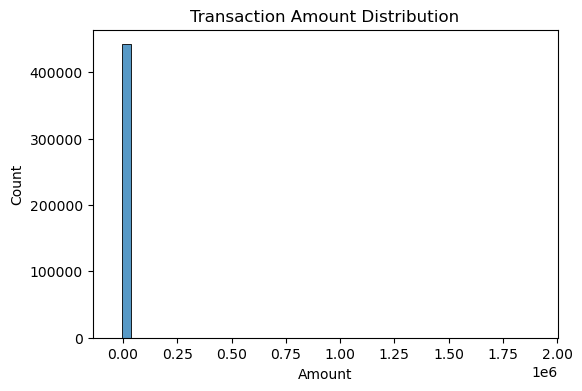

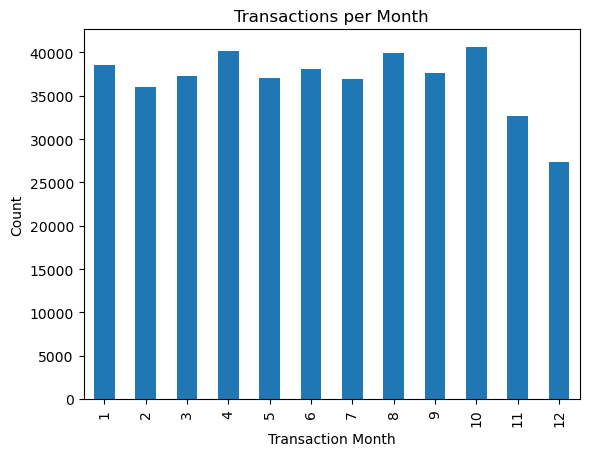

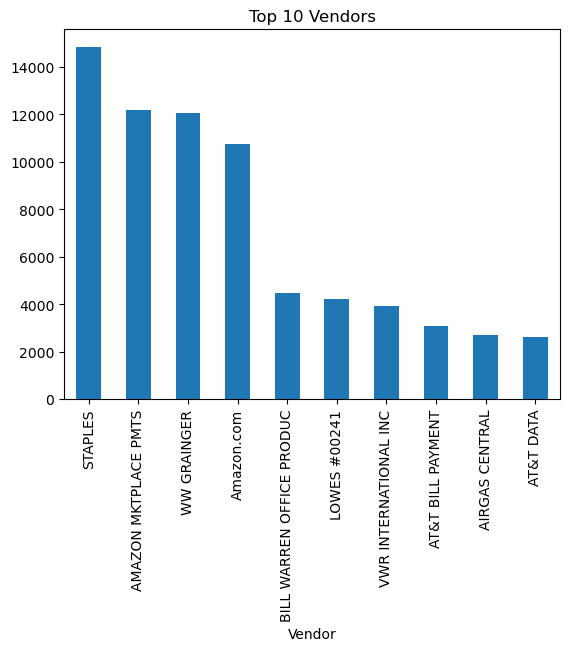

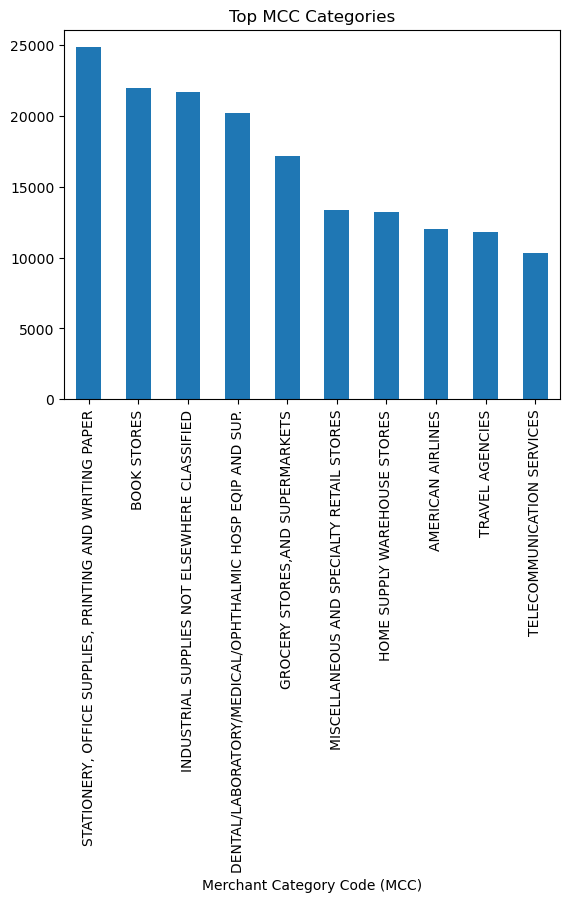

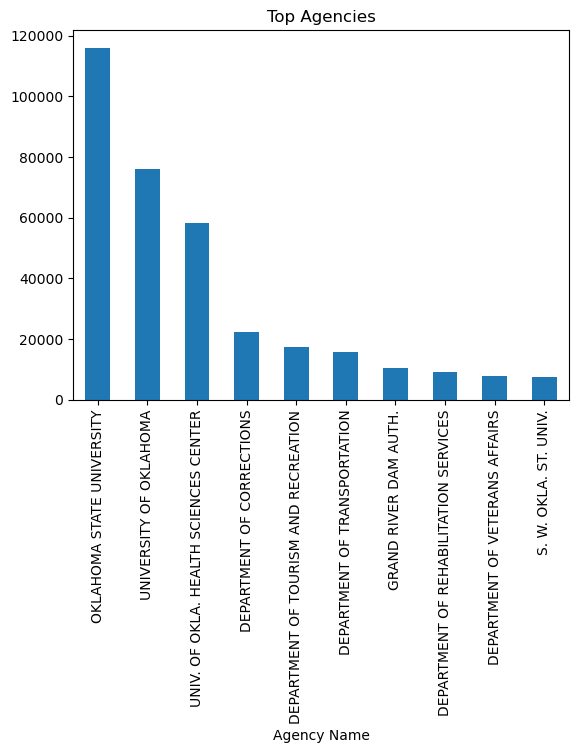

In [347]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%m/%d/%Y %I:%M:%S %p')
df['Posted Date'] = pd.to_datetime(df['Posted Date'], format='%m/%d/%Y %I:%M:%S %p')

df['Transaction Day'] = df['Transaction Date'].dt.day
df['Transaction Month'] = df['Transaction Date'].dt.month

# Amount distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

# Transactions over time
df.groupby('Transaction Month')['Amount'].count().plot(kind='bar')
plt.title('Transactions per Month')
plt.ylabel('Count')
plt.show()

# Top Vendors
df['Vendor'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Vendors')
plt.show()

# Top MCC Categories
df['Merchant Category Code (MCC)'].value_counts().head(10).plot(kind='bar')
plt.title('Top MCC Categories')
plt.show()

# Agency distribution
df['Agency Name'].value_counts().head(10).plot(kind='bar')
plt.title('Top Agencies')
plt.show()

In [349]:
print(df.shape)
print(df.info())
print(df.describe())

(442458, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442458 entries, 0 to 442457
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Year-Month                    442458 non-null  int64         
 1   Agency Number                 442458 non-null  int64         
 2   Agency Name                   442458 non-null  object        
 3   Cardholder Last Name          442458 non-null  object        
 4   Cardholder First Initial      442458 non-null  object        
 5   Description                   442458 non-null  object        
 6   Amount                        442458 non-null  float64       
 7   Vendor                        442458 non-null  object        
 8   Transaction Date              442458 non-null  datetime64[ns]
 9   Posted Date                   442458 non-null  datetime64[ns]
 10  Merchant Category Code (MCC)  442458 non-null  object        
 11  



The dataset contains 442,458 transactions and includes 11 original variables, both numeric and categorical. Key variables are:

| Variable                       |  Description                               |  
|--------------------------------|--------------------------------------------|  
Year-Month                       | Transaction period                         |
Agency Number and Name           | Organization responsible for the purchase           |
Cardholder Name                  | Individual responsible for the transaction |
Amount                           | Transaction value                          |
Transaction date and Posted date | Timing information of the transaction      |
Vendor                           | Merchant involved in the transaction       |
Merchant Category Code (MCC)     | Type or category of the merchant           |



In [352]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%m/%d/%Y %I:%M:%S %p')
df['Posted Date'] = pd.to_datetime(df['Posted Date'], format='%m/%d/%Y %I:%M:%S %p')

df['Cardholder'] = df['Cardholder Last Name'] + '_' + df['Cardholder First Initial'] + '_' + df['Agency Number'].astype(str)

## Feature Engineering

Additional variables were added to capture behavioral patterns that may indicate fraud.

**Posting Delay:** The time difference between transaction date and posting date. Unusually long delays may indicate suspicious or manipulated transactions. 

**Average Spend per Cardholder:** Represents the typical spending behavior of a cardholder and serves as a baseline for identifying unusual transactions.  

**Amount Ratio:** The ratio of transaction amount to the cardholder’s average spend. Higher values may indicate unusually large transactions and potential fraud.

**Vendor Frequency:** Measures how often a cardholder makes purchases from a specific vendor. Activity involving rarely used or new vendors may indicate suspicious behavior.

**Daily Transaction Count:** Number of transactions made by a cardholder in a day. A sudden spike may indicate fraudulent activity or card misuse. 

**Amount Deviation:** The difference between a transaction amount and the cardholder’s average spend. Large deviations may signal abnormal behavior.

In [445]:
#  Posting Delay
df['Posting Delay'] = (df['Posted Date'] - df['Transaction Date']).dt.days

#  Average Spend per Cardholder
df['Avg Spend Cardholder'] = df.groupby('Cardholder')['Amount'].transform('mean')

#  Amount Ratio 
df['Amount Ratio'] = df['Amount'] / (df['Avg Spend Cardholder'] + 1e-5)

#  Vendor Frequency
df['Vendor Frequency'] = df.groupby('Vendor')['Vendor'].transform('count')

#  Daily Transaction Count
df['Daily Transaction Count'] = df.groupby(['Cardholder','Transaction Date'])['Amount'].transform('count')

#  Amount Deviation
df['Amount Deviation'] = df['Amount'] - df['Avg Spend Cardholder']

In [357]:
print(df.columns)
df.head()

Index(['Year-Month', 'Agency Number', 'Agency Name', 'Cardholder Last Name',
       'Cardholder First Initial', 'Description', 'Amount', 'Vendor',
       'Transaction Date', 'Posted Date', 'Merchant Category Code (MCC)',
       'Transaction Day', 'Transaction Month', 'Cardholder', 'Posting Delay',
       'Avg Spend Cardholder', 'Amount Ratio', 'Vendor Frequency',
       'Daily Transaction Count', 'Amount Deviation'],
      dtype='object')


,Year-Month,Agency Number,Agency Name,Cardholder Last Name,Cardholder First Initial,Description,Amount,Vendor,Transaction Date,Posted Date,Merchant Category Code (MCC),Transaction Day,Transaction Month,Cardholder,Posting Delay,Avg Spend Cardholder,Amount Ratio,Vendor Frequency,Daily Transaction Count,Amount Deviation
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,GENERAL PURCHASE,890.00,NACAS,2013-07-30,2013-07-31,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,30,7,Mason_C_1000,1,246.983846,3.603474,9,4,643.016154
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,ROOM CHARGES,368.96,SHERATON HOTEL,2013-07-30,2013-07-31,SHERATON,30,7,Mason_C_1000,1,246.983846,1.493863,159,4,121.976154
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,GENERAL PURCHASE,165.82,SEARS.COM 9300,2013-07-29,2013-07-31,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,29,7,Massey_J_1000,2,400.652735,0.413875,118,1,-234.832735
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,GENERAL PURCHASE,96.39,WAL-MART #0137,2013-07-30,2013-07-31,"GROCERY STORES,AND SUPERMARKETS",30,7,Massey_T_1000,1,364.359929,0.264546,2548,2,-267.969929
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,HAMMERMILL COPY PLUS COPY EA,125.96,STAPLES DIRECT,2013-07-30,2013-07-31,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",30,7,Mauro-Herrera_M_1000,1,93.818028,1.342599,1450,1,32.141972


## Exploratory Data Analysis on New Features

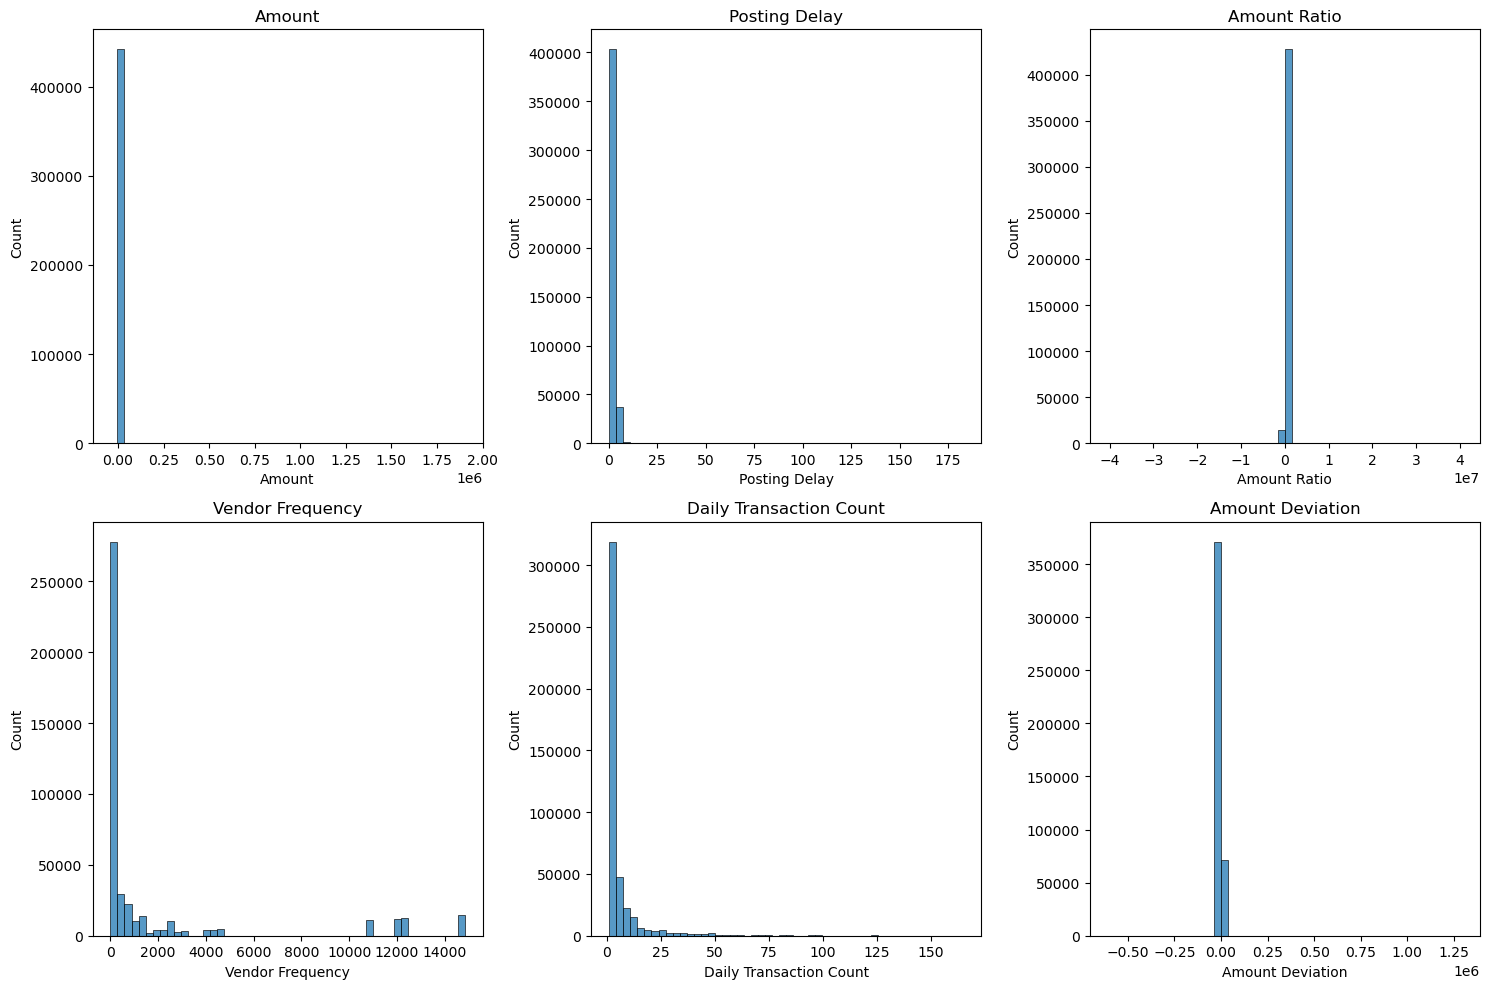

In [360]:
num_cols = ['Amount', 'Posting Delay', 'Amount Ratio',
            'Vendor Frequency', 'Daily Transaction Count', 'Amount Deviation']

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50)
    plt.title(col)

plt.tight_layout()
plt.show()

The histograms show that most variables are right-skewed, with values concentrated at the lower end and long tails toward higher values. Transaction Amount has a wide range, with most values being small and a few extreme outliers. Posting Delay is concentrated between 0–2 days but shows a right tail for higher delays. Vendor Frequency and Daily Transaction Count are also right-skewed, with most observations at low values and a few high-frequency cases. Amount Ratio shows a large spread with extreme values, indicating potential anomalies. Overall, the distributions suggest the presence of skewness and outliers in the data.

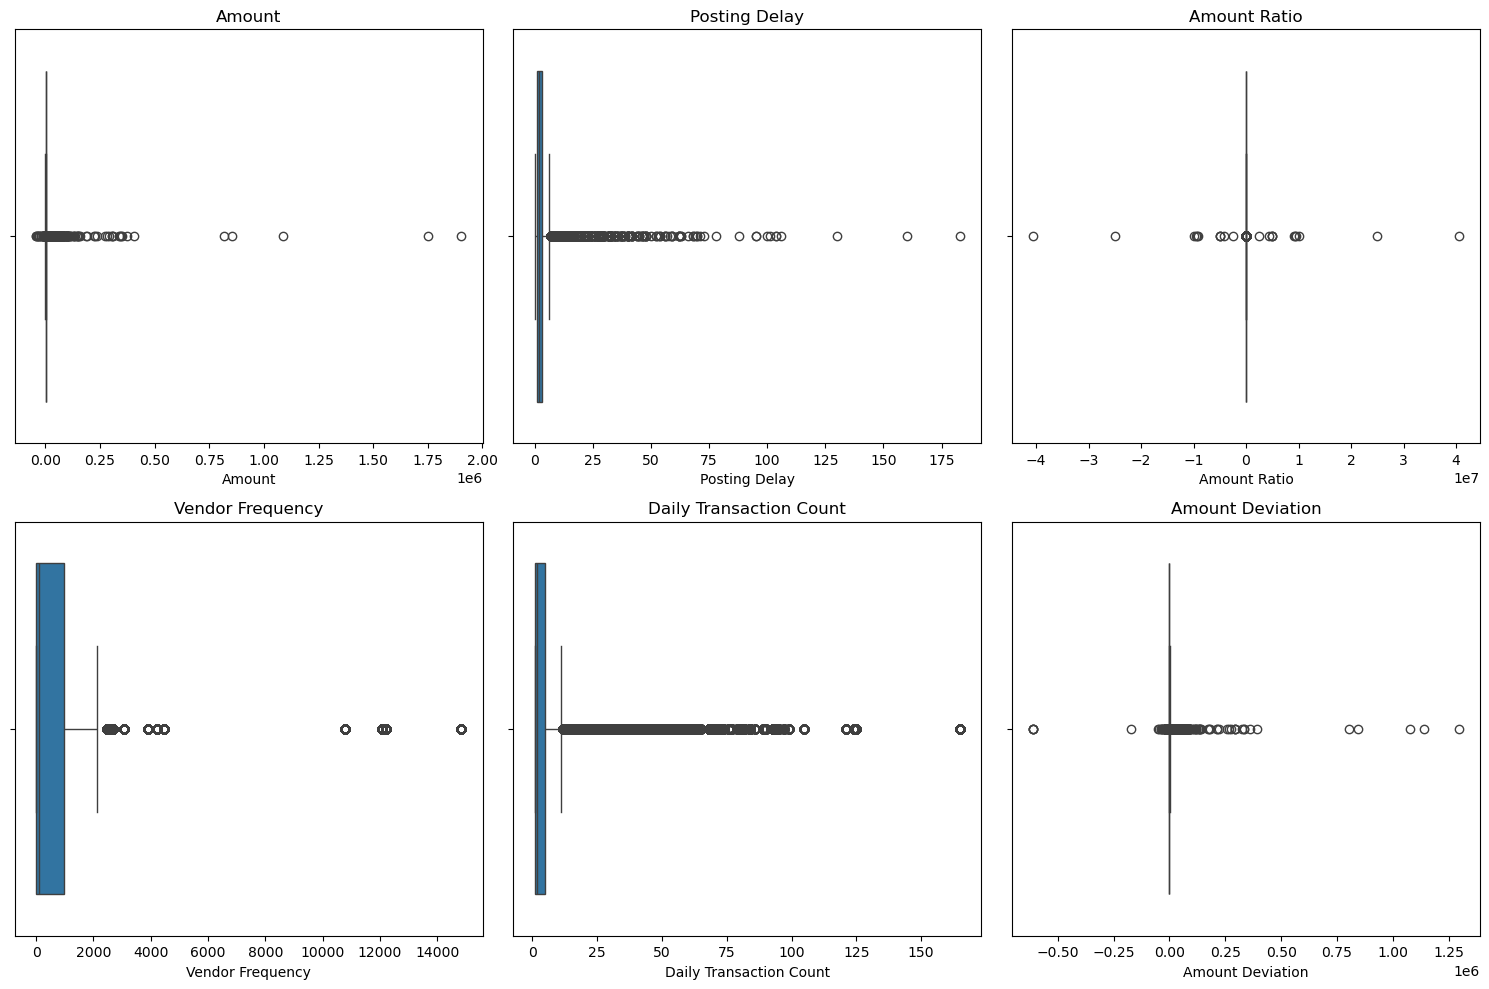

In [363]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

The boxplots show strong presence of outliers across all variables. Posting Delay includes some very high values, while Vendor Frequency and Daily Transaction Count are concentrated at low values with a few large outliers. Amount Ratio and Amount Deviation show wide spread with extreme values on both sides, indicating possible anomalies.

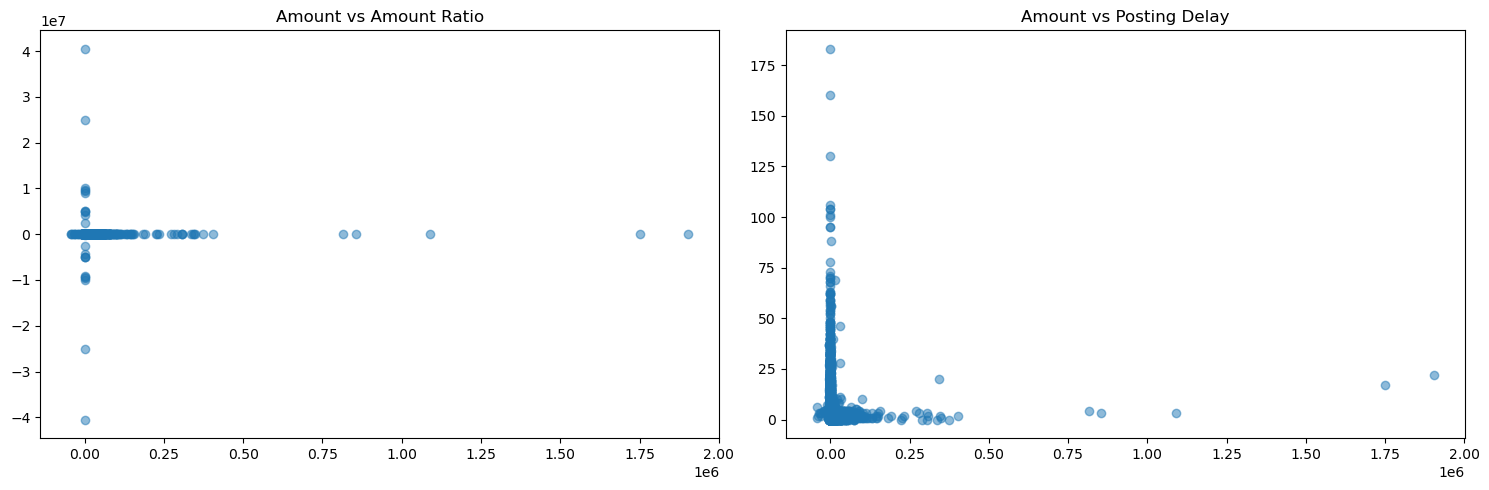

In [366]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.scatter(df['Amount'], df['Amount Ratio'], alpha=0.5)
plt.title('Amount vs Amount Ratio')

plt.subplot(1,2,2)
plt.scatter(df['Amount'], df['Posting Delay'], alpha=0.5)
plt.title('Amount vs Posting Delay')

plt.tight_layout()
plt.show()

The scatter plots show that most transactions have low amounts, and in the Amount vs Posting Delay plot, most delays are under 10 days. A few transactions have very high amounts (above 1 million), and some show long posting delays up to 180 days. These extreme points may indicate potential anomalies.

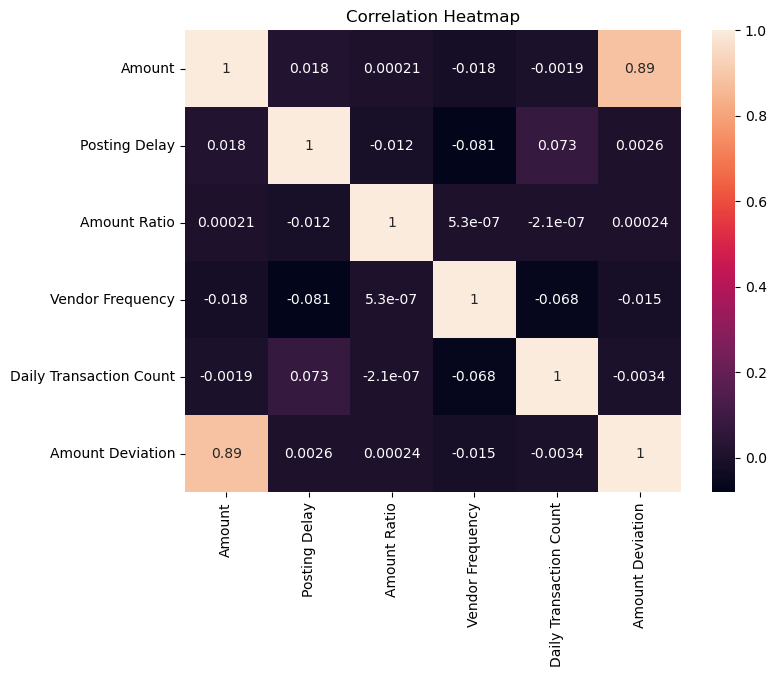

In [369]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Most variables show weak correlations, as seen in the heatmap. The correlation between Amount and Amount Deviation is strong (0.89), while the rest of the relationships are close to zero, indicating that the variables are largely independent.

In [372]:
features = df[num_cols]

# Remove infinity
features = features.replace([np.inf, -np.inf], np.nan)

# Fill missing values
features = features.fillna(features.median())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## Fraud Detection

## K-Nearest Neighbors (KNN)

KNN is a distance-based algorithm that identifies anomalies by comparing each data point with its nearest neighbors. Points that are significantly farther away from surrounding data are considered outliers.

This approach is effective in detecting unusual patterns, such as rare events or extreme values, that do not align with the majority of the data. By focusing on local structure rather than overall distribution, KNN can detect anomalies that may be missed by global statistical methods.

Advantages:

- Captures local anomalies that differ from nearby points.
- Can detect unusual patterns in complex or high-dimensional data.
- Intuitive and easy to understand.

Limitations:

- Computationally expensive for large datasets.
- Choice of k and distance metric strongly affects results.
- Dense clusters can hide anomalies if outliers are close to other points.




In [376]:
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from pyod.models.iforest import IForest

# KNN 
knn_model = KNN(contamination=0.05)
knn_model.fit(X_scaled)
df['KNN_Outlier'] = knn_model.labels_ == 1

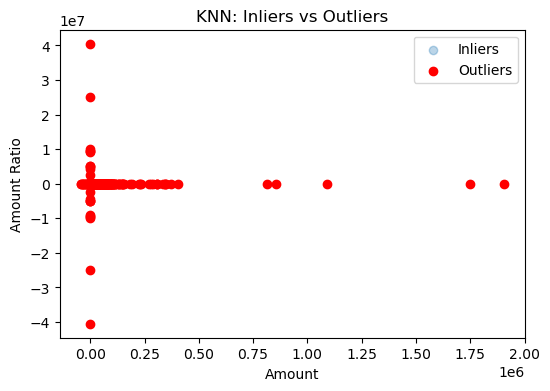

Total KNN Outliers detected: 22123


In [378]:
plt.figure(figsize=(6,4))

plt.scatter(df[~df['KNN_Outlier']]['Amount'],
            df[~df['KNN_Outlier']]['Amount Ratio'],
            label='Inliers', alpha=0.3)

plt.scatter(df[df['KNN_Outlier']]['Amount'],
            df[df['KNN_Outlier']]['Amount Ratio'],
            color='red', label='Outliers')

plt.title('KNN: Inliers vs Outliers')
plt.xlabel('Amount')
plt.ylabel('Amount Ratio')
plt.legend()
plt.show()

print("Total KNN Outliers detected:", df['KNN_Outlier'].sum())

## Local Outlier Factor (LOF)

LOF is a density-based algorithm that identifies anomalies by comparing how densely a data point is surrounded by other points. If a point lies in a region with significantly lower density than nearby points, it is considered an outlier.

This method is especially useful for detecting local anomalies. These are points that may appear normal overall but are unusual within their immediate surroundings. By focusing on relative density rather than just distance, LOF can identify subtle anomalies in datasets with varying data distributions.

LOF is commonly used in applications such as fraud detection, network intrusion detection, and identifying unusual patterns in sensor or IoT data.

Advantages:

- Detects local anomalies that distance-based methods may miss.
- Adapts to clusters of different densities.
- Works well in high-dimensional spaces.

Limitations:

- Computationally intensive for very large datasets.
- Sensitive to the choice of the number of neighbors.
- Interpretation can be less intuitive compared to simpler methods like KNN.



In [381]:
# LOF 
lof_model = LOF(contamination=0.05)
lof_model.fit(X_scaled)
df['LOF_Outlier'] = lof_model.labels_ == 1

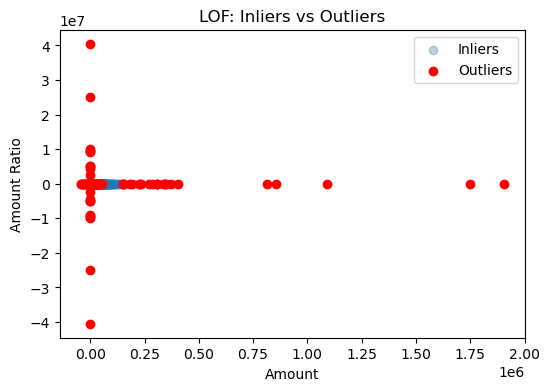

Total LOF Outliers detected: 22123


In [383]:
plt.figure(figsize=(6,4))

plt.scatter(df[~df['LOF_Outlier']]['Amount'],
            df[~df['LOF_Outlier']]['Amount Ratio'],
            label='Inliers', alpha=0.3)

plt.scatter(df[df['LOF_Outlier']]['Amount'],
            df[df['LOF_Outlier']]['Amount Ratio'],
            color='red', label='Outliers')

plt.title('LOF: Inliers vs Outliers')
plt.xlabel('Amount')
plt.ylabel('Amount Ratio')
plt.legend()
plt.show()

print("Total LOF Outliers detected:", df['LOF_Outlier'].sum())

## Isolation Forest

Isolation Forest is a tree-based algorithm that isolates anomalies by randomly partitioning data points. Points that are easier to isolate, requiring fewer splits, are considered outliers. This method is efficient for large datasets and is effective in detecting rare and distinct anomalies.

This method is particularly efficient for large datasets and high-dimensional data, making it suitable for applications such as fraud detection, network security, and detecting unusual patterns in sensor or log data. Unlike density- or distance-based methods, Isolation Forest does not require calculating distances or densities, which lowers computational cost and improves its robustness to complex or irregular data distributions.

Advantages:

- Efficient and scalable for large datasets.
- Can detect both global and subtle anomalies.
- Does not rely on distance or density measures, reducing sensitivity to feature scaling.


Limitations:

- Performance can degrade if anomalies are not well-separated from normal points.
- Results can vary due to randomness in tree construction.
- Less intuitive to interpret compared to methods like KNN or LOF.





In [386]:
# Isolation Forest 
iso_model = IForest(contamination=0.05, random_state=42)
iso_model.fit(X_scaled)
df['ISO_Outlier'] = iso_model.labels_ == 1

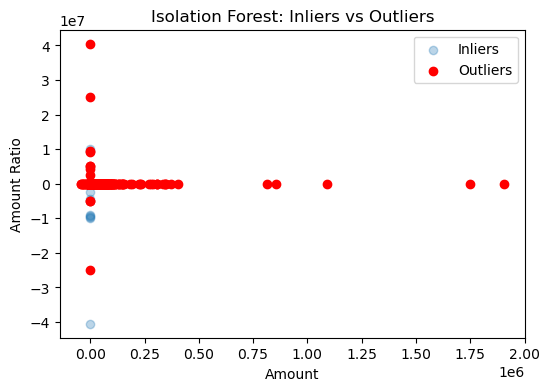

Total Isolation Forest Outliers detected: 22123


In [388]:
plt.figure(figsize=(6,4))

plt.scatter(df[~df['ISO_Outlier']]['Amount'],
            df[~df['ISO_Outlier']]['Amount Ratio'],
            label='Inliers', alpha=0.3)

plt.scatter(df[df['ISO_Outlier']]['Amount'],
            df[df['ISO_Outlier']]['Amount Ratio'],
            color='red', label='Outliers')

plt.title('Isolation Forest: Inliers vs Outliers')
plt.xlabel('Amount')
plt.ylabel('Amount Ratio')
plt.legend()
plt.show()

print("Total Isolation Forest Outliers detected:", df['ISO_Outlier'].sum())

**All three models identified the same set of abnormal transactions, indicating a high level of agreement between the methods in detecting potential outliers.**

In [391]:
df['Total_Outliers'] = df[['KNN_Outlier','LOF_Outlier','ISO_Outlier']].sum(axis=1)

## Agreement Map

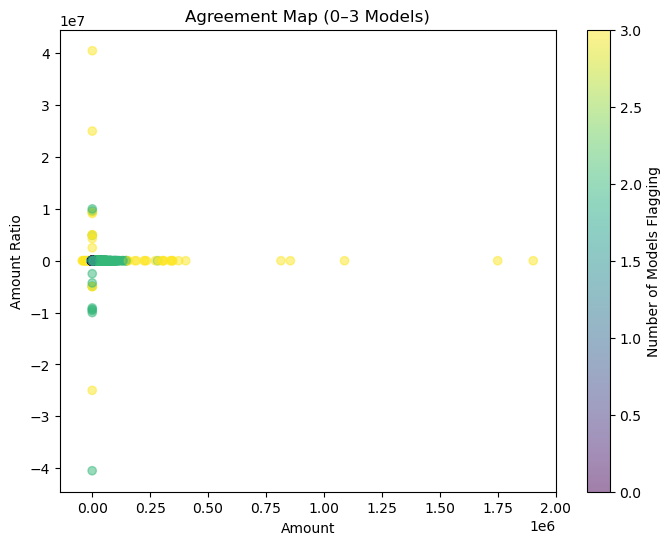

In [394]:
# Agreement Map

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Amount'],
    df['Amount Ratio'],
    c=df['Total_Outliers'],
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(scatter, label='Number of Models Flagging')
plt.xlabel('Amount')
plt.ylabel('Amount Ratio')
plt.title('Agreement Map (0–3 Models)')
plt.show()

## Consensus Outliers: Strict Agreement (All 3 Models)

A strict consensus approach was used to ensure the highest reliability of anomaly detection. Only transactions flagged as outliers by all three models (KNN, LOF, and Isolation Forest) were considered consensus outliers. This reduces false positives and focuses on the most evident anomalies.

In [397]:
# ALL 3 MODELS (strict consensus)
df['Consensus_Outlier_3'] = df['Total_Outliers'] == 3

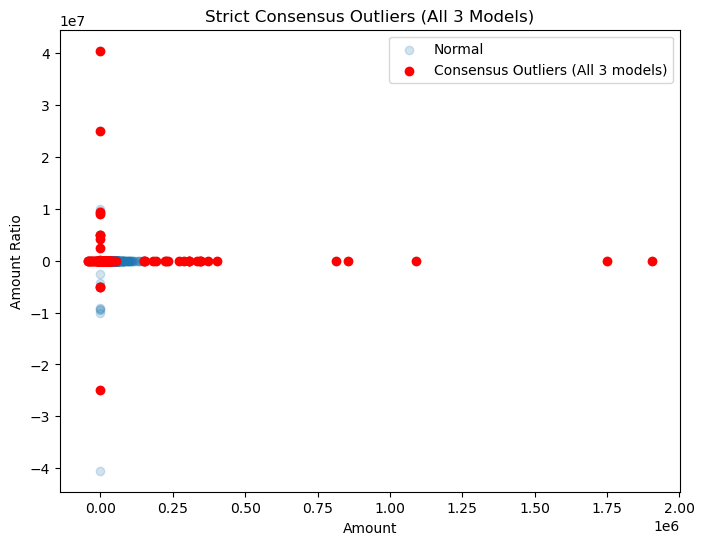

In [399]:
plt.figure(figsize=(8,6))

plt.scatter(df['Amount'], df['Amount Ratio'], alpha=0.2, label='Normal')

plt.scatter(df[df['Consensus_Outlier_3']]['Amount'],
            df[df['Consensus_Outlier_3']]['Amount Ratio'],
            color='red', label='Consensus Outliers (All 3 models)')

plt.legend()
plt.xlabel('Amount')
plt.ylabel('Amount Ratio')
plt.title('Strict Consensus Outliers (All 3 Models)')
plt.show()

In [401]:
print("KNN Outliers:", df['KNN_Outlier'].sum())
print("LOF Outliers:", df['LOF_Outlier'].sum())
print("Isolation Forest Outliers:", df['ISO_Outlier'].sum())
print("Strict Consensus Outliers (All 3 Models):", df['Consensus_Outlier_3'].sum())

KNN Outliers: 22123
LOF Outliers: 22123
Isolation Forest Outliers: 22123
Strict Consensus Outliers (All 3 Models): 2085


In [403]:
total = len(df)
outliers = df['Consensus_Outlier_3'].sum()

print("Total Transactions:", total)
print("Consensus Outliers:", outliers)
print("Percentage of Outliers (Strict Consensus):", (outliers/total)*100)

Total Transactions: 442458
Consensus Outliers: 2085
Percentage of Outliers (Strict Consensus): 0.47123116770405327



All three models individually detected 22,123 outliers. By using the strict consensus, the number of credible anomalies was reduced to 2,085, representing only 0.47% of the total transactions. This demonstrates the importance of combining multiple models for higher precision in detecting abnormal transactions.





In [406]:
df[df['Consensus_Outlier_3']]['Amount'].describe()

count    2.085000e+03
mean     6.998104e+03
std      7.176056e+04
min     -4.286304e+04
25%     -2.780000e+02
50%      7.618000e+02
75%      2.279660e+03
max      1.903858e+06
Name: Amount, dtype: float64

In [408]:
df[df['Consensus_Outlier_3']]['Posting Delay'].describe()

count    2085.000000
mean        3.460432
std         5.504578
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max       104.000000
Name: Posting Delay, dtype: float64

In [410]:
# Top suspicious transactions
suspicious = df[df['Consensus_Outlier_3'] == True]

suspicious_sorted = suspicious.sort_values(by='Amount', ascending=False)

suspicious_sorted[['Cardholder','Amount','Vendor','Amount Ratio','Posting Delay']].head(10)

,Cardholder,Amount,Vendor,Amount Ratio,Posting Delay
218925,77000_7_77000,1903858.37,PAYMENT ADJUSTMENT,3.126000,22
212076,77000_7_77000,1750379.98,PAYMENT ADJUSTMENT,2.874000,17
251918,Cardholder_e_98000,1089180.00,PELCO STRUCTURAL LLC,87.025543,3
365832,Cardholder_e_98000,855343.00,PELCO STRUCTURAL LLC,68.341954,3
251488,Cardholder_e_98000,814934.76,EMC CORPORATION,65.113333,4
251616,Cardholder_e_98000,403490.75,EMC CORPORATION,32.238934,2
367166,Cardholder_e_98000,373150.26,TK CONSTRUCTIO US LLC,29.814727,0
400124,Johnson_C_34500,348053.75,NORTH AMERICAN SALT CO,23.580223,1
250934,Cardholder_e_98000,345176.00,"MOTOROLA, INC. - ONLINE",27.579582,2
246477,81500_8_81500,343148.50,PAYMENT ADJUSTMENT,1.999471,20


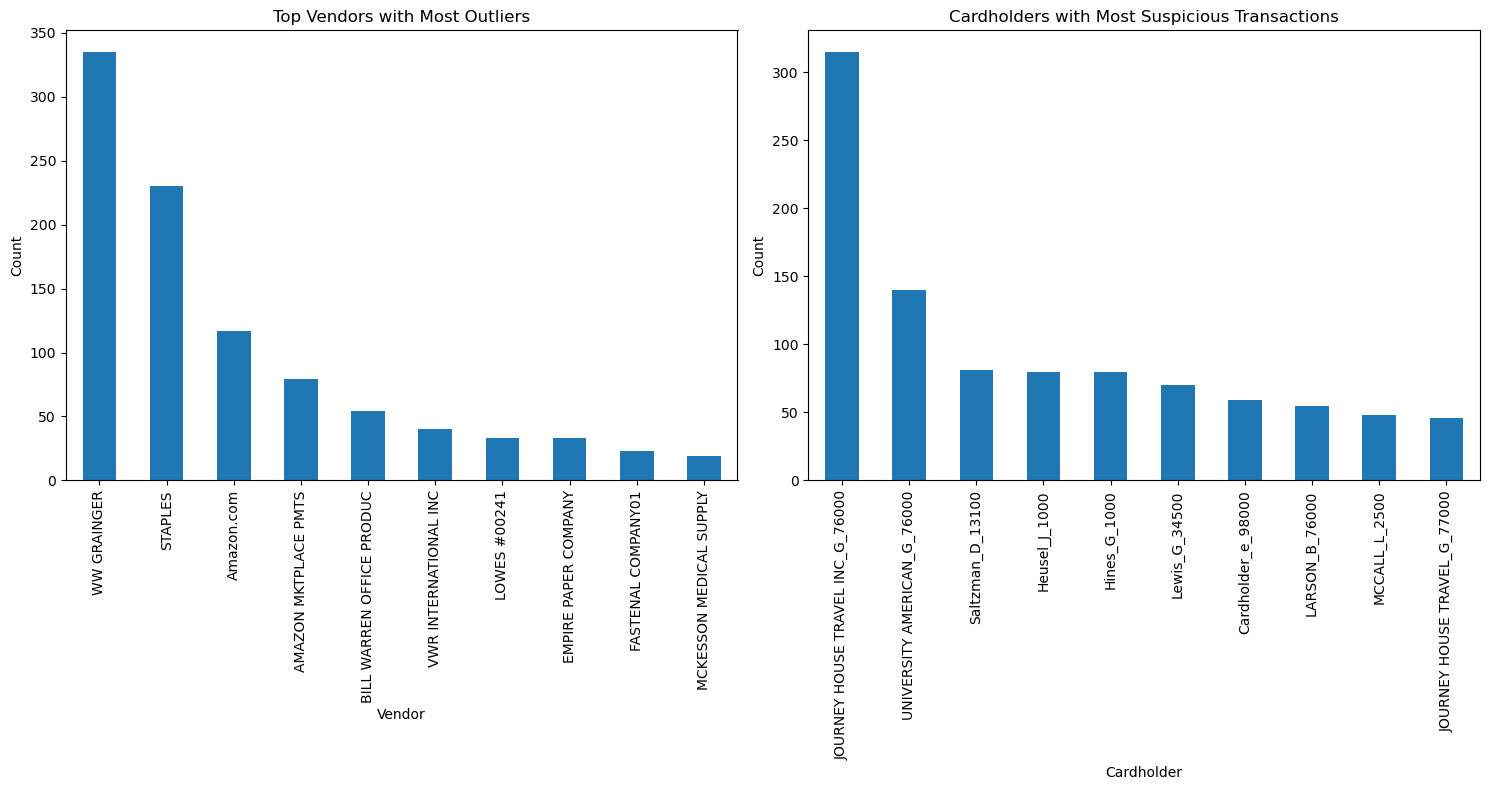

In [412]:
outlier_vendors = df[df['Consensus_Outlier_3'] == True]['Vendor'].value_counts().head(10)
outlier_cardholder = df[df['Consensus_Outlier_3'] == True]['Cardholder'].value_counts().head(10)

plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
outlier_vendors.plot(kind='bar')
plt.title('Top Vendors with Most Outliers')
plt.xlabel('Vendor')
plt.ylabel('Count')

plt.subplot(1,2,2)
outlier_cardholder.plot(kind='bar')
plt.title('Cardholders with Most Suspicious Transactions')
plt.xlabel('Cardholder')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [414]:
high_risk = df[
    (df['Amount Ratio'] > 5) &
    (df['Consensus_Outlier_3'] == True)
]

high_risk[['Cardholder','Amount','Vendor','Amount Ratio']].head(10)

,Cardholder,Amount,Vendor,Amount Ratio
121,Munday_T_1000,3086.17,ANIXTER INC,8.469489e+00
256,Heusel_J_1000,1691.68,WW GRAINGER,5.563695e+00
4047,Barrett_M_1000,91.04,PAPER PLUS 20400204065,9.104000e+06
9576,Tornakian_M_1000,4896.48,HOOVER FENCE CO.,8.496547e+00
10852,Tornakian_M_1000,3862.88,OSWALT RESTUARANT SUPPLY,6.703007e+00
12016,Hines_G_1000,3823.78,VWR INTERNATIONAL INC,7.546325e+00
23448,Tornakian_M_1000,4847.04,HOOVER FENCE CO.,8.410757e+00
23739,Tornakian_M_1000,3960.00,EGGELHOF INC,6.871533e+00
25328,Bowers_R_1000,881.39,LOWES #00241,5.230261e+00
27561,Heusel_J_1000,2302.54,WW GRAINGER,7.572726e+00


**Key Insights**

- Only the most extreme transactions were flagged, indicating strong anomalies.
- Transactions with very high Amount Ratios dominate this group, making them the most unusual. The highest Amount Ratio observed is 9,104,000, proving these are extreme.
- A few vendors appear multiple times among these extreme outliers, suggesting concentrated unusual activity. The most frequent vendors are WW GRAINGER (335 flagged transactions) and STAPLES (230 flagged transactions).
- Some cardholders consistently appear in these outliers, indicating potentially abnormal spending patterns. The top cardholders are JOURNEY HOUSE TRAVEL INC_G_76000 (315 flagged transactions) and UNIVERSITY AMERICAN_G_76000 (140 flagged transactions).
- Most flagged transactions have short posting delays, but a few are unusually long, further highlighting unusual behavior. The mean posting delay is 3.46 days, but some go up to 104 days.
- Using only transactions flagged by all three models isolates the most reliable anomalies, reducing false positives and improving precision.

## Consensus Outliers (>= 2 Models)

Transactions flagged as outliers by two or more models (KNN, LOF, or Isolation Forest) were considered consensus outliers. This captures more potential anomalies than the strict three-model method, while still reducing false positives and focusing on the most suspicious transactions.

In [418]:
df['Consensus_Outlier_>=2'] = df['Total_Outliers'] >= 2

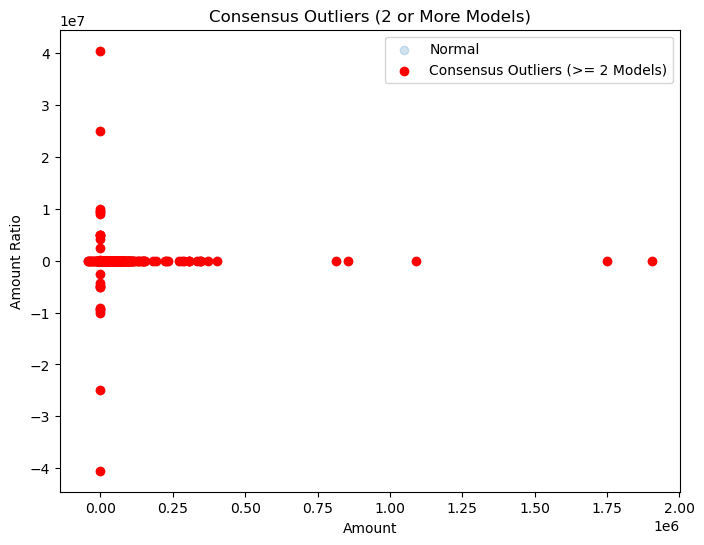

In [420]:
plt.figure(figsize=(8,6))

plt.scatter(df['Amount'], df['Amount Ratio'], alpha=0.2, label='Normal')

plt.scatter(df[df['Consensus_Outlier_>=2']]['Amount'],
            df[df['Consensus_Outlier_>=2']]['Amount Ratio'],
            color='red', label='Consensus Outliers (>= 2 Models)')

plt.legend()
plt.xlabel('Amount')
plt.ylabel('Amount Ratio')
plt.title('Consensus Outliers (2 or More Models)')
plt.show()

In [422]:
print("KNN Outliers:", df['KNN_Outlier'].sum())
print("LOF Outliers:", df['LOF_Outlier'].sum())
print("Isolation Forest Outliers:", df['ISO_Outlier'].sum())
print("Consensus Outliers ( >=2 Models):", df['Consensus_Outlier_>=2'].sum())

KNN Outliers: 22123
LOF Outliers: 22123
Isolation Forest Outliers: 22123
Consensus Outliers ( >=2 Models): 14308


In [424]:
total = len(df)
outliers_2 = df['Consensus_Outlier_>=2'].sum()

print("Total Transactions:", total)
print("Consensus Outliers:", outliers_2)
print("Percentage of Outliers ( >=2 models):", (outliers_2/total)*100)

Total Transactions: 442458
Consensus Outliers: 14308
Percentage of Outliers ( >=2 models): 3.233753260196448


All three models individually detected 22,123 outliers. Considering transactions flagged by two or more models gives 14,308 consensus outliers, representing 3.23% of total transactions. This shows that combining models improves anomaly detection while reducing false positives.

In [427]:
df[df['Consensus_Outlier_>=2']]['Amount'].describe()

count    1.430800e+04
mean     4.563889e+03
std      2.882426e+04
min     -4.286304e+04
25%      1.735850e+02
50%      1.513590e+03
75%      4.013125e+03
max      1.903858e+06
Name: Amount, dtype: float64

In [429]:
df[df['Consensus_Outlier_>=2']]['Posting Delay'].describe()

count    14308.000000
mean         2.787741
std          4.629929
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        183.000000
Name: Posting Delay, dtype: float64

In [431]:
# Top suspicious transactions
suspicious = df[df['Consensus_Outlier_>=2'] == True]

suspicious_sorted = suspicious.sort_values(by='Amount', ascending=False)

suspicious_sorted[['Cardholder','Amount','Vendor','Amount Ratio','Posting Delay']].head(10)

,Cardholder,Amount,Vendor,Amount Ratio,Posting Delay
218925,77000_7_77000,1903858.37,PAYMENT ADJUSTMENT,3.126000,22
212076,77000_7_77000,1750379.98,PAYMENT ADJUSTMENT,2.874000,17
251918,Cardholder_e_98000,1089180.00,PELCO STRUCTURAL LLC,87.025543,3
365832,Cardholder_e_98000,855343.00,PELCO STRUCTURAL LLC,68.341954,3
251488,Cardholder_e_98000,814934.76,EMC CORPORATION,65.113333,4
251616,Cardholder_e_98000,403490.75,EMC CORPORATION,32.238934,2
367166,Cardholder_e_98000,373150.26,TK CONSTRUCTIO US LLC,29.814727,0
400124,Johnson_C_34500,348053.75,NORTH AMERICAN SALT CO,23.580223,1
250934,Cardholder_e_98000,345176.00,"MOTOROLA, INC. - ONLINE",27.579582,2
246477,81500_8_81500,343148.50,PAYMENT ADJUSTMENT,1.999471,20


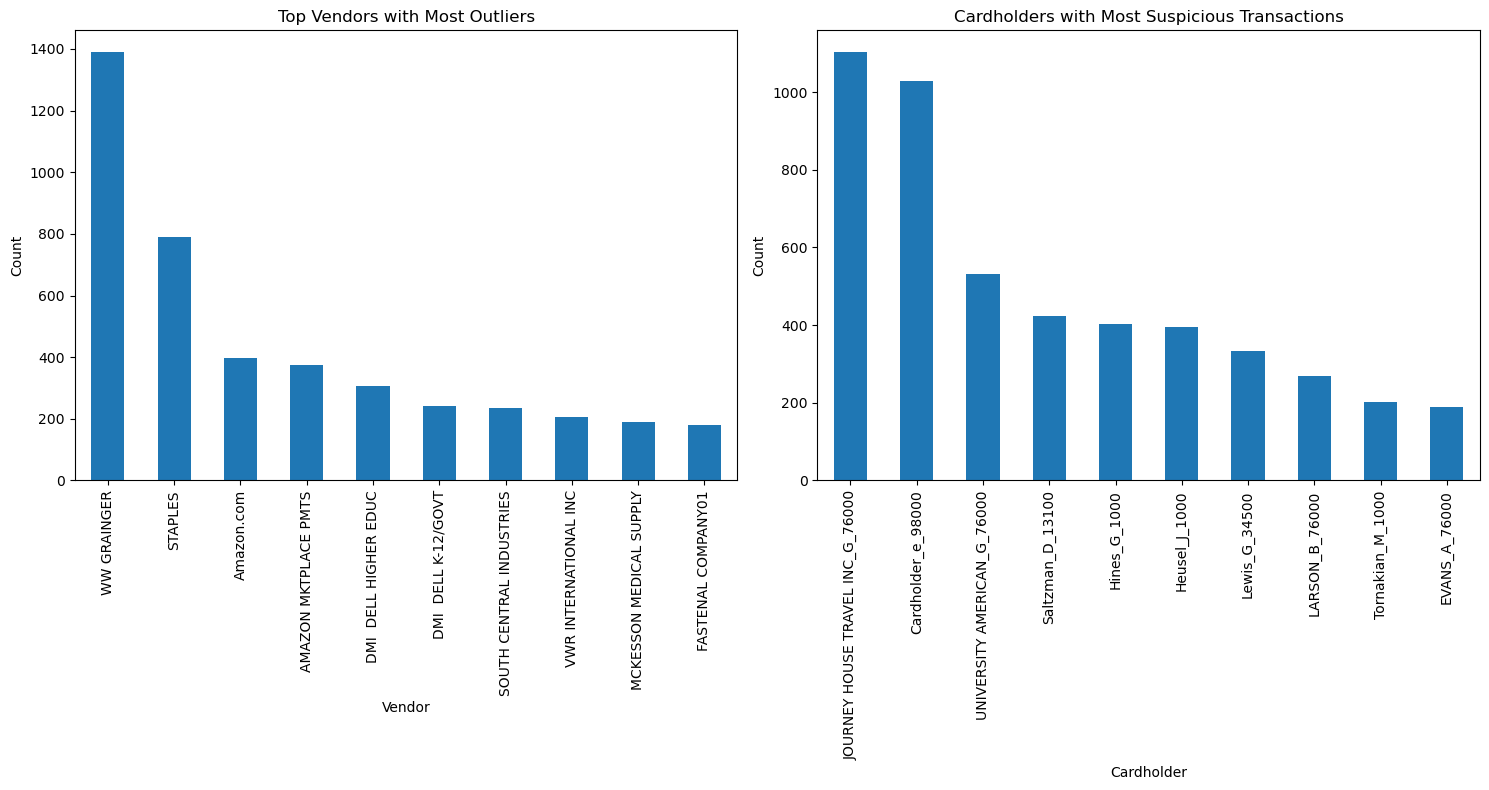

In [433]:
outlier_vendors = df[df['Consensus_Outlier_>=2'] == True]['Vendor'].value_counts().head(10)
outlier_cardholder = df[df['Consensus_Outlier_>=2'] == True]['Cardholder'].value_counts().head(10)

plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
outlier_vendors.plot(kind='bar')
plt.title('Top Vendors with Most Outliers')
plt.xlabel('Vendor')
plt.ylabel('Count')

plt.subplot(1,2,2)
outlier_cardholder.plot(kind='bar')
plt.title('Cardholders with Most Suspicious Transactions')
plt.xlabel('Cardholder')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [435]:
high_risk = df[
    (df['Amount Ratio'] > 5) &
    (df['Consensus_Outlier_>=2'] == True)
]

high_risk[['Cardholder','Amount','Vendor','Amount Ratio']].head(10)

,Cardholder,Amount,Vendor,Amount Ratio
121,Munday_T_1000,3086.17,ANIXTER INC,8.469489
169,Aichele_C_1000,2497.36,VWR INTERNATIONAL INC,5.638564
256,Heusel_J_1000,1691.68,WW GRAINGER,5.563695
340,Heusel_J_1000,1831.89,"GRIMSLEY'S, INC.",6.024825
352,Hunt_A_1000,4362.80,FISHER SCI HUS,5.784525
789,Ritthaler_B_1000,4546.61,WWW.NEWEGG.COM,10.876216
1114,Clark_M_1000,3000.00,THE PHD PROJECT ASSOCIAT,5.694143
1241,Heusel_J_1000,1841.00,STILLWATER MILLING COMP,6.054787
1244,Heusel_J_1000,2216.76,MURPHY SANITARY SUPPLY LL,7.290608
1363,Heusel_J_1000,2370.00,STILLWATER WINNELSON C,7.794593


**Key Insights**

- A larger set of transactions was flagged compared to the strict consensus, capturing more potential anomalies while still reducing false positives. Amounts vary widely, with many transactions significantly higher than typical values, highlighting unusual activity.
- Transactions with high Amount Ratios dominate this group, indicating potentially risky or abnormal spending patterns. Some of these reach values above 10, showing extreme behavior.
- Several vendors appear repeatedly among these outliers, such as WW GRAINGER (1,391 transactions) and STAPLES (791 transactions), showing concentrated unusual activity.
- Certain cardholders consistently appear in these flagged transactions, for example, JOURNEY HOUSE TRAVEL INC_G_76000 (1,104 transactions) and Cardholder_e_98000 (1,030 transactions), suggesting repeated anomalous spending.
- Most flagged transactions have short posting delays, though some are longer, further emphasizing unusual behavior patterns.
- Using the ≥2 consensus approach improves anomaly detection by including transactions that multiple models consider suspicious, increasing coverage without relying solely on the strictest criteria.


### Comparison of Strict and Two-or-More Models Consensus

- Strict consensus focuses on the most extreme anomalies with 2,085 transactions, while the approach using two or more models captures a broader set of 14,308 transactions.
- Both methods show unusual spending patterns, but strict consensus highlights the most critical cases, whereas the two-or-more models approach gives a more complete picture.
- Transactions with high Amount Ratios appear in both sets, with the two-or-more approach including some moderately unusual cases not caught by strict consensus.
- A few vendors and cardholders repeatedly appear in flagged transactions in both approaches, showing concentrated unusual activity, with the two-or-more set including a larger group.
- Most flagged transactions have short posting delays, but occasional long delays in both sets indicate irregular activity.


In [440]:
df.to_csv('final_output_with_outliers.csv', index=False)